In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("../data/landlord_data_for_training_w_lagged_features_20_coldstart.csv")

In [5]:
data['session'].nunique()

44

Number of invocations per sessions - some stats

In [8]:
data[['session', 'tid']].groupby('session').count().min(), data[['session', 'tid']].groupby('session').count().max(), data[['session', 'tid']].groupby('session').count().mean()

(tid    818
 dtype: int64,
 tid    3052
 dtype: int64,
 tid    1784.863636
 dtype: float64)

E2E time distribution

avg e2e times 1.216 seconds


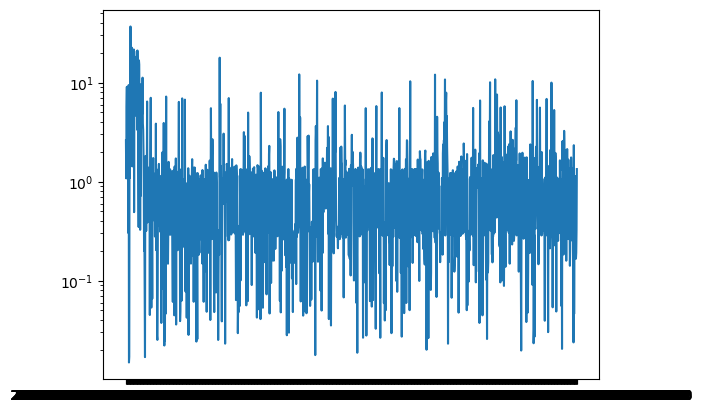

In [14]:
session = 0
session_data = data[data['session'] == session].sort_values(by='invocation_timestamp').reset_index(drop=True)
print(f"avg e2e times {round(session_data['e2etime'].mean(), 3)} seconds")
plt.figure()
plt.plot(session_data['invocation_timestamp'].values, session_data['e2etime'].values)
plt.yscale('log')  # Latency is best viewed on a log scale
plt.show()

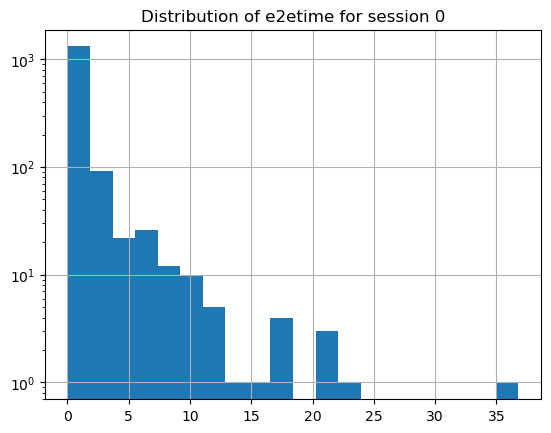

In [26]:
plt.figure()
session_data['e2etime'].hist(bins=20)
plt.title(f"Distribution of e2etime for session {session}")
plt.yscale('log')
plt.show()

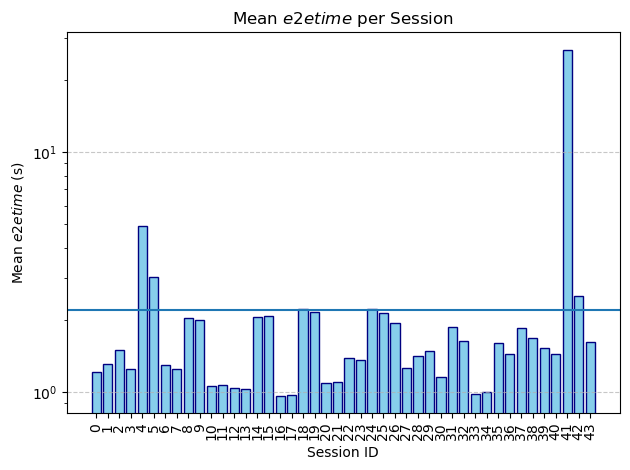

In [21]:
def get_session_stats(df, session_col='session', value_col='e2etime'):
    """
    Calculates the mean value per session and ensures the data is sorted.
    """
    # Group by session and calculate mean
    stats = df.groupby(session_col)[value_col].mean().reset_index()
    
    # Sort by session id to ensure a logical order on the x-axis
    stats = stats.sort_values(session_col)
    return stats

def plot_mean_latency(stats, session_col='session', value_col='e2etime', save_path='session_latency(log).png'):
    """
    Creates a bar plot for mean latency per session.
    """
    # 1. Setup plot labels and aesthetics
    # Convert session IDs to strings for categorical-style x-axis spacing
    x_labels = stats[session_col].astype(str)
    y_values = stats[value_col]

    plt.bar(x_labels, y_values, color='skyblue', edgecolor='navy')
    
    # 2. Formatting
    plt.title('Mean $e2etime$ per Session')
    plt.xlabel('Session ID')
    plt.ylabel('Mean $e2etime$ (s)')
    plt.yscale('log')
    plt.axhline(y_values.mean())
    # Rotate labels if you have many sessions
    plt.xticks(rotation=90)
    
    # Add a grid for easier reading of values
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 3. Finalize
    plt.tight_layout()
    plt.savefig(save_path)

session_stats = get_session_stats(data)
plot_mean_latency(session_stats)

### Session 41 data looks suspicious. Removing it before further analysis

In [49]:
data = data[data['session']!=41].reset_index(drop=True)

Effect of fqdn on e2e time - Does fqdn affect?

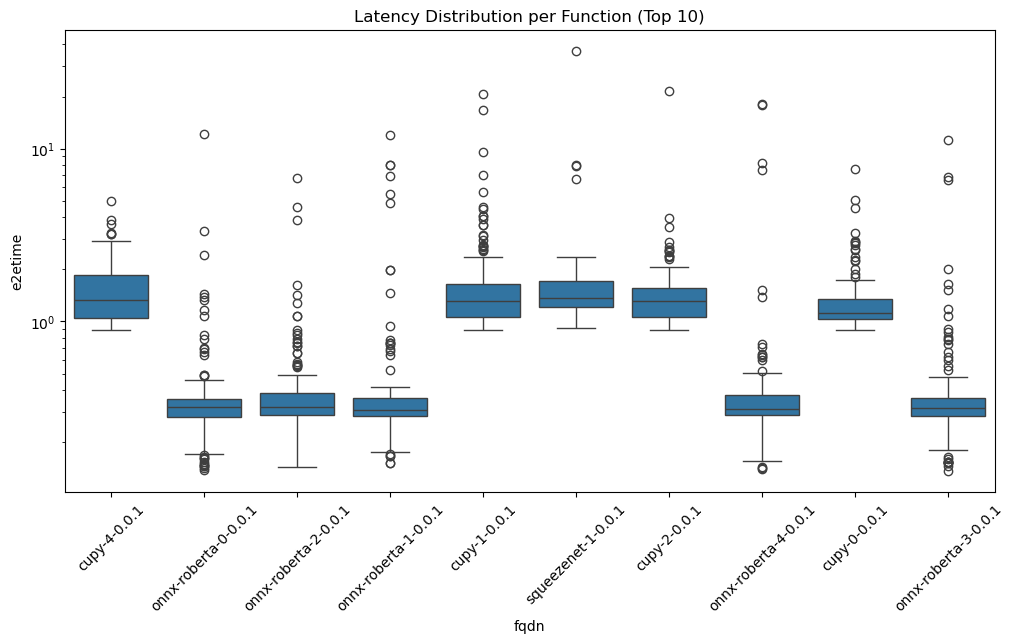

In [50]:
top_functions = session_data['fqdn'].value_counts().nlargest(10).index
subset = session_data[session_data['fqdn'].isin(top_functions)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x='fqdn', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title("Latency Distribution per Function (Top 10)")
plt.show()

GPU representation - Looking at two features here:
1. `num_running_funcs_filled` - Effect of number of functions running currently on e2etime
2. `is_cold_start` - a binary flag that indicate whether the execution is going to be a cold start or not

Number of functions running currently at the time of invocation

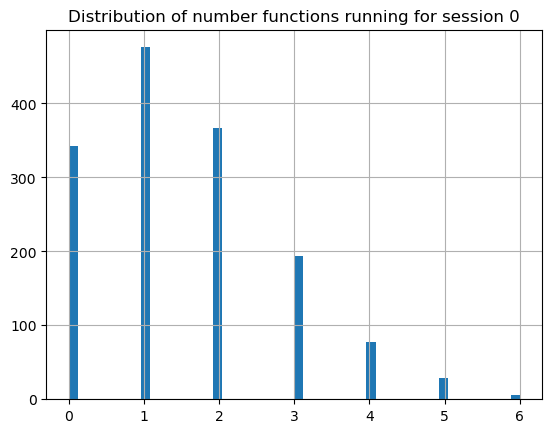

In [51]:
plt.figure()
session_data['num_running_funcs_filled'].hist(bins=50)
plt.title(f"Distribution of number functions running for session {session}")
plt.show()

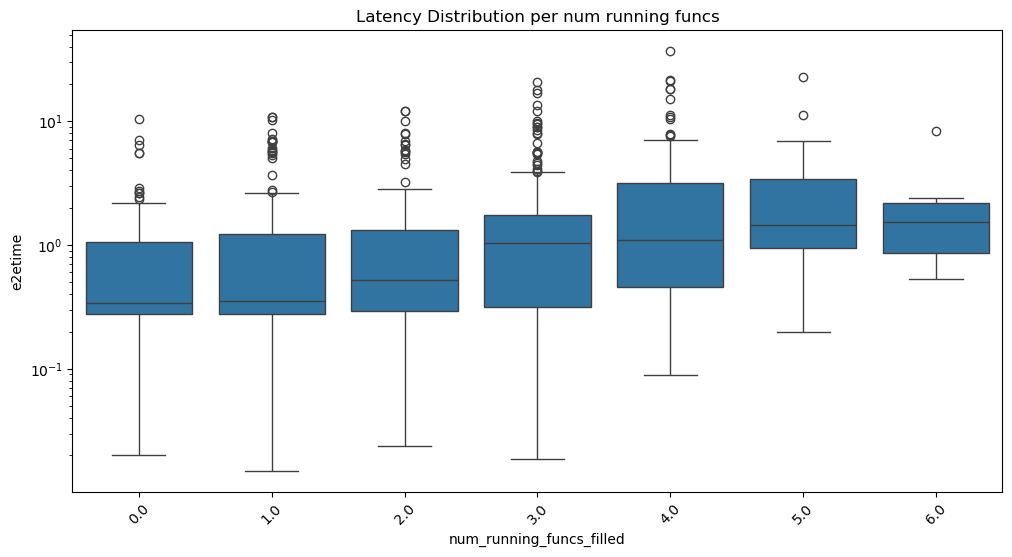

In [52]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=session_data, x='num_running_funcs_filled', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title("Latency Distribution per num running funcs")
plt.show()

is_cold_start

In [62]:
session_data['is_cold_start'].value_counts()

is_cold_start
0    1430
1      62
Name: count, dtype: int64

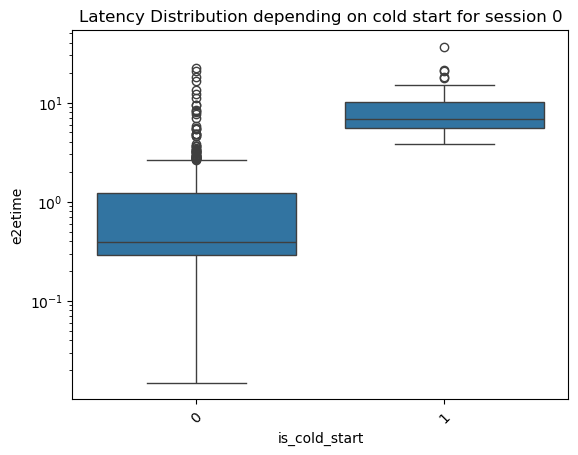

In [66]:
plt.figure()
sns.boxplot(data=session_data, x='is_cold_start', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title(f"Latency Distribution depending on cold start for session {session}")
plt.show()

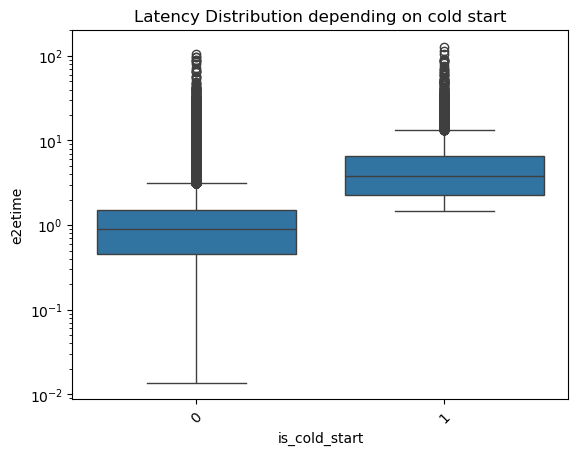

In [67]:
plt.figure()
sns.boxplot(data=data, x='is_cold_start', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title("Latency Distribution depending on cold start")
plt.show()

Queue length stats - Here, we look at 2 features
1. `target_queue_len` - queue length of the incoming fqdn
2. `others_len_queue` - sum of queue lengths of all fqdn queue lengths except the incoming fqdn

In [56]:
data['target_queue_len'].value_counts()

target_queue_len
0.0    75718
1.0     1301
2.0       23
3.0        7
4.0        4
7.0        1
6.0        1
5.0        1
Name: count, dtype: int64

In [57]:
data['others_len_queue'].value_counts()

others_len_queue
0.0     58681
1.0      9602
2.0      3651
3.0      1860
4.0      1110
5.0       680
6.0       413
7.0       239
8.0       163
9.0       130
10.0      130
11.0       91
12.0       58
13.0       52
15.0       29
14.0       27
19.0       27
18.0       22
16.0       20
17.0       17
22.0       11
24.0        7
30.0        7
20.0        5
25.0        4
28.0        4
32.0        3
21.0        3
29.0        2
31.0        2
23.0        2
27.0        2
33.0        1
26.0        1
Name: count, dtype: int64

Correlation between `target_queue_len` and `e2etime`

In [55]:
(session_data['target_queue_len']).corr(session_data['e2etime']), (data['target_queue_len']).corr(data['e2etime']) 

(0.10400106717358255, 0.23859662572143636)

In [58]:
(session_data['others_len_queue']).corr(session_data['e2etime']), (data['others_len_queue']).corr(data['e2etime']) 

(0.46392587408911945, 0.474394681721937)

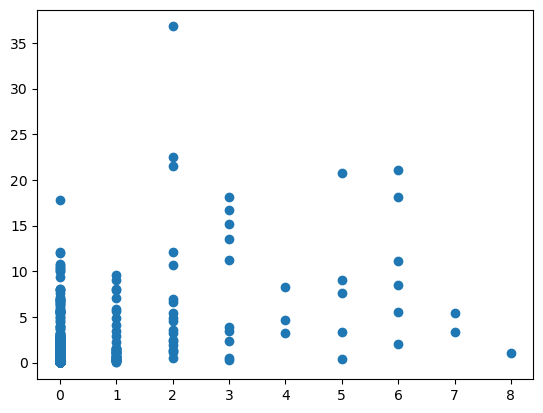

In [59]:
plt.figure()
plt.scatter(session_data['others_len_queue'], session_data['e2etime'])
plt.show()

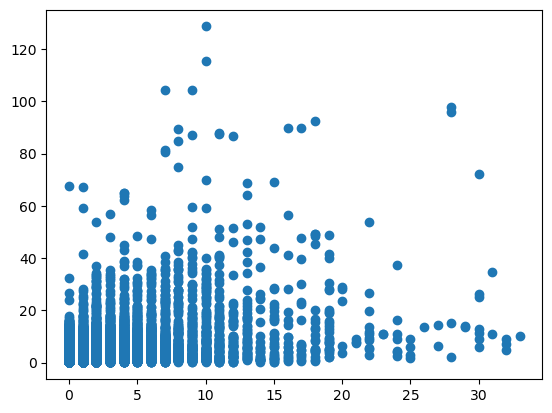

In [68]:
plt.figure()
plt.scatter(data['others_len_queue'], data['e2etime'])
plt.show()